# Project 3
# Mental Health and CGPA: A Classification Study of Student Performance

https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data

## Introductions
**Michael Shahine** uniqname: *shahine*

Hi teaching team, I am a first year MSI student I come from a background mainly in front end development and was interested in MSI based on a recommendation from my friend in the program + an interest in Basketball analytics and business analytics. I play club Water Polo for the University in my free time, and play a lot basketball as well.

**Rebecca Falash:** uniqname: *rfalash*

I am a second year Dual degree student studying Geospatial data science at SEAS and Big Data at UMSI. I am interested in electrification, environmental modeling, and load analysis. In my free time I race on the UM cycling team. 

**Mason Fisher:** uniqname: *masonaf*

Hi teaching team, I am a first year MSI student. I come from a background in commmunications, but I am currently working for the football team as a sports scientist. I am interesting in sports analytics. In my free time, I enjoy reading and playing basketball. 


**Overview**

As a team we decided to study the influence of social media and outward pressures on a students performance at school. We have included two datasets for our analysis which includes a social media user activity dataset that contains information on students habit activities as well as other demographic information such as gender, income level, relationship status, etc. This dataset will help us identify patterns that are connected to the specific habits the student have and its connection to other lifestyle factors. The second dataset is the student mental health assessments which contains information on a students mental health in broken down variables including stress, depression, and anxiety levels. For our analysis, we grouped and averaged the data by age and gender to study the patterns between lifestyle factors and mental health outcomes.

**Motivation**
We chose this topic for our project because we understand the pressures that come with being a student. As a team we wanted to better understand how outside factors can influence our mental health. We wanted to see what sort of habits have an effect on us as students and if there was any differences based off of things like age, gender, gpa etc. This is more and more relevant with the increasing amount of technology nowadays and the less and less time people are spending doing outside activities, making researching this even more important. We take a deeper look at this below and start to paint a picture. 

**Data Sources**

1. https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

2. https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data

NOTE: The Student Habits vs Academic Performance Data set is a simulated data set and for this project we only used the Students mental health assessments data.

These two datasets compliment each other because one captures behaviors and demographics such as social media usage, sleep, and study habits. While the other captures mental health outcomes such as stress, anxiety, and depression. When using both together you can study the connection between lifestyle factors, mental health, and academic performance in relation to age and gender.


# Machine Learning Goal
1. How does Mental Health Factors Affect GPA
- We will look at this through classification 

## Preprocessing Data

In [22]:
import csv
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score




In [23]:
df = pd.read_csv('df_MH_export.csv')

### Data cleaning and handling of issues: 20 points


In [24]:
print("Missing by column:\n", df.isna().sum().sort_values(ascending=False))

Missing by column:
 Substance_Use                  15
CGPA                           12
Age                             0
Relationship_Status             0
Semester_Credit_Load            0
Extracurricular_Involvement     0
Financial_Stress                0
Chronic_Illness                 0
Family_History                  0
Counseling_Service_Use          0
Social_Support                  0
Course                          0
Diet_Quality                    0
Physical_Activity               0
Sleep_Quality                   0
Anxiety_Score                   0
Depression_Score                0
Stress_Level                    0
Gender                          0
Residence_Type                  0
dtype: int64


In [25]:
df = df.dropna(subset=["CGPA"]) #remove rows with missing CGPA because its our target variable

df['CGPA_bin'] = pd.cut(df['CGPA'], bins=[0, 2, 3.3, 4.0], labels=['low', 'medium', 'high'])
df = df.drop(columns=["CGPA"]) #drop CGPA from the features dataframe

df.head()

,Age,Course,Gender,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type,CGPA_bin
0,25,Others,Male,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus,high
1,24,Engineering,Female,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus,medium
2,19,Business,Female,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus,high
3,19,Computer Science,Male,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus,high
4,18,Business,Male,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus,high


For the initial data cleaning and handling we first checked for missing values. There were 12 missing values in the CGPA column which is our prediction variable. Because of that, we chose to drop all of those columns as filling them through the preprocessing stages would lead to incorrect conclusions. 

### Feature scaling and normalization; one-hot encoding/categorical variable handling: 20 points



In [26]:
# This is the predicition column.
df['CGPA_bin'] = pd.cut(df['CGPA'], bins=[0, 2, 3.3, 4.0], labels=['low', 'medium', 'high'])

Rather then predicting the raw number, we created bins to sort out the CGPA into 3 different sections (low, medium, and high)

In [27]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["CGPA_bin"]  # keeps class balance
)

# separate features/target
X_train = train_df.drop(columns=["CGPA_bin"])
y_train = train_df["CGPA_bin"]
X_test  = test_df.drop(columns=["CGPA_bin"])
y_test  = test_df["CGPA_bin"]

print(f"Train: {X_train.shape}   Validation: {X_test.shape}")

Train: (5608, 19)   Validation: (1402, 19)


Before pre-processing the data, we split it into testing and training sets to avoid leakage. This will allow us to training the model on a subset of the whole data and use the remainder to validate the results. 

In [28]:
print("Train class counts:")
print(y_train.value_counts(dropna=False).sort_index())

print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True, dropna=False).sort_index())

print("\nTest class counts:")
print(y_test.value_counts(dropna=False).sort_index())

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True, dropna=False).sort_index())

Train class counts:
CGPA_bin
low          0
medium    1481
high      4127
Name: count, dtype: int64

Train class proportions:
CGPA_bin
low       0.000000
medium    0.264087
high      0.735913
Name: proportion, dtype: float64

Test class counts:
CGPA_bin
low          0
medium     370
high      1032
Name: count, dtype: int64

Test class proportions:
CGPA_bin
low       0.000000
medium    0.263909
high      0.736091
Name: proportion, dtype: float64


KeyboardInterrupt: 

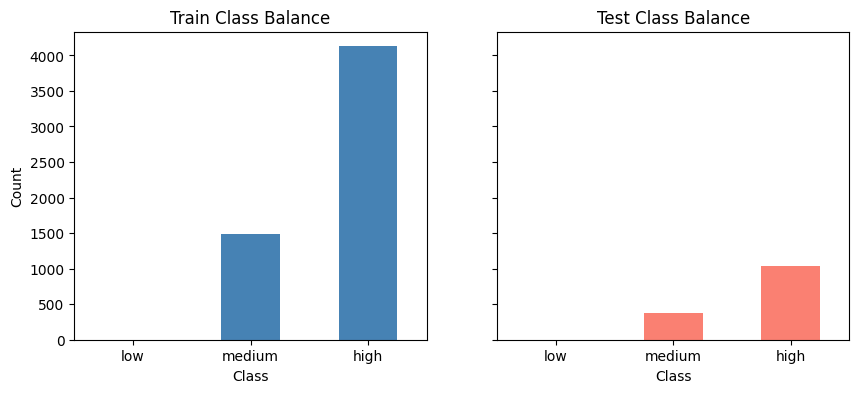

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

y_train.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Train Class Balance", color="steelblue"
)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

y_test.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Test Class Balance", color="salmon"
)
axes[1].set_xlabel("Class")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

When splitting the data, it is important that there is class balance between the training and testing set. As seen in the table output as well as the plots, the proportions are nearly the same concluding they are balanced. Having balance ensures there will be limited bias during the training and testing process. 

In [ ]:
# numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
# skewness = X_train[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)

# print('Numeric feature skewness (sorted by absolute skew):')
# print(skewness.round(2))

In [ ]:
print("\nUnique values for categorical features:")
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")


Unique values for categorical features:
Course: 6 unique values
Gender: 2 unique values
Sleep_Quality: 3 unique values
Physical_Activity: 3 unique values
Diet_Quality: 3 unique values
Social_Support: 3 unique values
Relationship_Status: 3 unique values
Substance_Use: 3 unique values
Counseling_Service_Use: 3 unique values
Family_History: 2 unique values
Chronic_Illness: 2 unique values
Extracurricular_Involvement: 3 unique values
Residence_Type: 3 unique values


In [ ]:
df.dtypes

Age                               int64
Course                           object
Gender                           object
Stress_Level                      int64
Depression_Score                  int64
Anxiety_Score                     int64
Sleep_Quality                    object
Physical_Activity                object
Diet_Quality                     object
Social_Support                   object
Relationship_Status              object
Substance_Use                    object
Counseling_Service_Use           object
Family_History                   object
Chronic_Illness                  object
Financial_Stress                  int64
Extracurricular_Involvement      object
Semester_Credit_Load              int64
Residence_Type                   object
CGPA_bin                       category
dtype: object

In [ ]:
num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print("Prepared shapes:", X_train_prep.shape, X_test_prep.shape)

Prepared shapes: (5608, 45) (1402, 45)


We split the training data into numeric and categorical data to apply the preprocessing pipeline. For numeric we used SimpleImputer with median because ... then use StandardScaler because ...

For Categorical we use simpleImputer with most_frequent because.. then use OneHotEncoder because ... 

Then applied both to the testing and training data. 

### Dimensionality reduction techniques: 20 points



In [ ]:
X_train_prep_dense = X_train_prep
X_test_prep_dense  = X_test_prep


pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_prep_dense)
X_test_pca  = pca.transform(X_test_prep_dense)

print("Before PCA:", X_train_prep_dense.shape, X_test_prep_dense.shape)
print("After PCA: ", X_train_pca.shape, X_test_pca.shape)
print("Explained variance ratio (sum):", np.sum(pca.explained_variance_ratio_).round(4))


Before PCA: (5608, 45) (1402, 45)
After PCA:  (5608, 26) (1402, 26)
Explained variance ratio (sum): 0.9505


WHY USE PCA / purpose of this

### Preprocessing justification and impact analysis: 20 points

Re-enforce justifications

## Clustering or Classification Analysis 

###  Clear definition and justification of goals: 10 points

Classification = Use when you bin and label GPA into categories (Low/Medium/High)

You create labeled groups
You predict which category a student falls into

Clearly define your analytical goal and the rationale behind choosing either clustering or classification.
If classification:
Choose and implement at least two different classifiers.
Optimize parameters for each classifier and evaluate their performance using appropriate metrics.
Interpret and analyze the classification results, discussing the comparative effectiveness of the classifiers used.

For this project, We chose classification because we created clear GPA categories (Low, Medium, High) from the CGPA column, which gave labeled outcomes to predict. Our goal is to understand how factors like stress level, sleep quality, mental health scores, and lifestyle habits influence a student’s academic performance category. Since the data already has meaningful features that could impact GPA, classification is more appropriate than clustering because we are predicting a known label rather than discovering unknown groups. Below we will implement two classifiers: a Decision Tree and a Random Forest. Evaluating both models using  to see how well they handled the different GPA categories. 

### Implementation of chosen techniques: 20 points

In [30]:
# Decision Tree Classifier, SVM Classifier, Random Forest Classifier

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}

print(f"{'Model':<30} {'AUC mean':>10} {'AUC std':>9} {'Acc mean':>10} {'Acc std':>9}")
print('-' * 73)

cv_results = []
for name, clf in models.items():
    auc = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='roc_auc_ovo')
    acc = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='accuracy')
    
    cv_results.append({
        'Model': name,
        'AUC mean': auc.mean(),
        'AUC std': auc.std(),
        'Acc mean': acc.mean(),
        'Acc std': acc.std()
    })
    
    print(f"{name:<30} {auc.mean():>10.3f} {auc.std():>9.3f} {acc.mean():>10.3f} {acc.std():>9.3f}")

cv_results_df = pd.DataFrame(cv_results).sort_values('Acc mean', ascending=False)
best_model_name = cv_results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nBest model by CV accuracy: {best_model_name}")



Model                            AUC mean   AUC std   Acc mean   Acc std
-------------------------------------------------------------------------
Decision Tree                       0.905     0.013      0.910     0.009
Random Forest                       0.990     0.001      0.942     0.007
Support Vector Machine              0.998     0.000      0.973     0.005

Best model by CV accuracy: Support Vector Machine


**Model selection justification:**

1. Which model did you choose as your final model, and why?
2. Did you tune any hyperparameters? If so, what did you try and what did you settle on?
3. Is there anything surprising in the comparison table? What might explain it?


For our final model, we chose the Support Vector Machine (SVM) because it performed the best out of all the models we tested. Based on our cross-validation results, SVM had the highest accuracy (0.973) and AUC (0.998), and also had almost no variation, which shows it was very consistent. We tested three models: Decision Tree, Random Forest, and SVM. For hyperparameters, we set the Decision Tree with a max depth of 10 and minimum samples split of 10 to reduce overfitting, and for Random Forest we used 100 trees. For SVM, we used the RBF kernel, which worked best for capturing more complex patterns in the data. One thing that stood out was how much worse the Decision Tree performed compared to the others, likely because it overfits easily. Random Forest did better since it combines multiple trees, but SVM still outperformed it. This is probably because SVM is better at finding clear boundaries between the GPA categories when the data is more complex. Overall, SVM gave us the most accurate and reliable results, so we chose it as our final model.


### Parameter optimization and method tuning: 20 points

### Performance evaluation and metric selection: 20 points

### Interpretation and discussion of results: 30 points